In [437]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [438]:
df_month = pd.read_csv('D:\\repos\\ML_innovise\\notebooks\\df_train_dqc.csv')
df_month_test = pd.read_csv('D:\\repos\\ML_innovise\\notebooks\\df_test_dqc.csv')


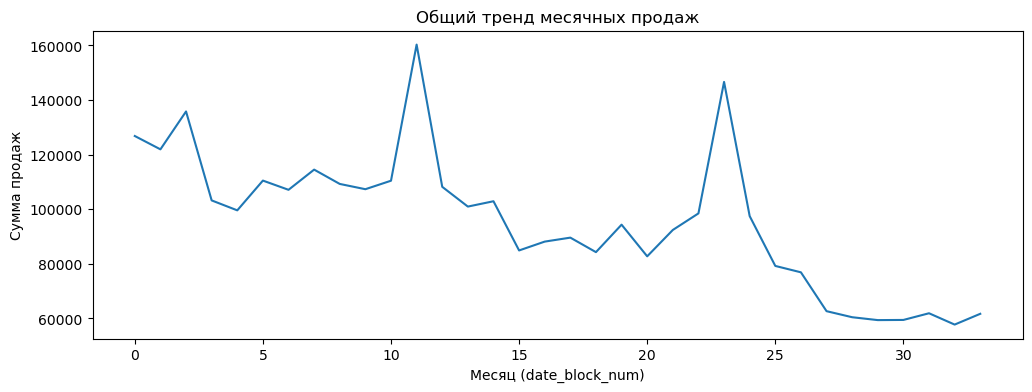

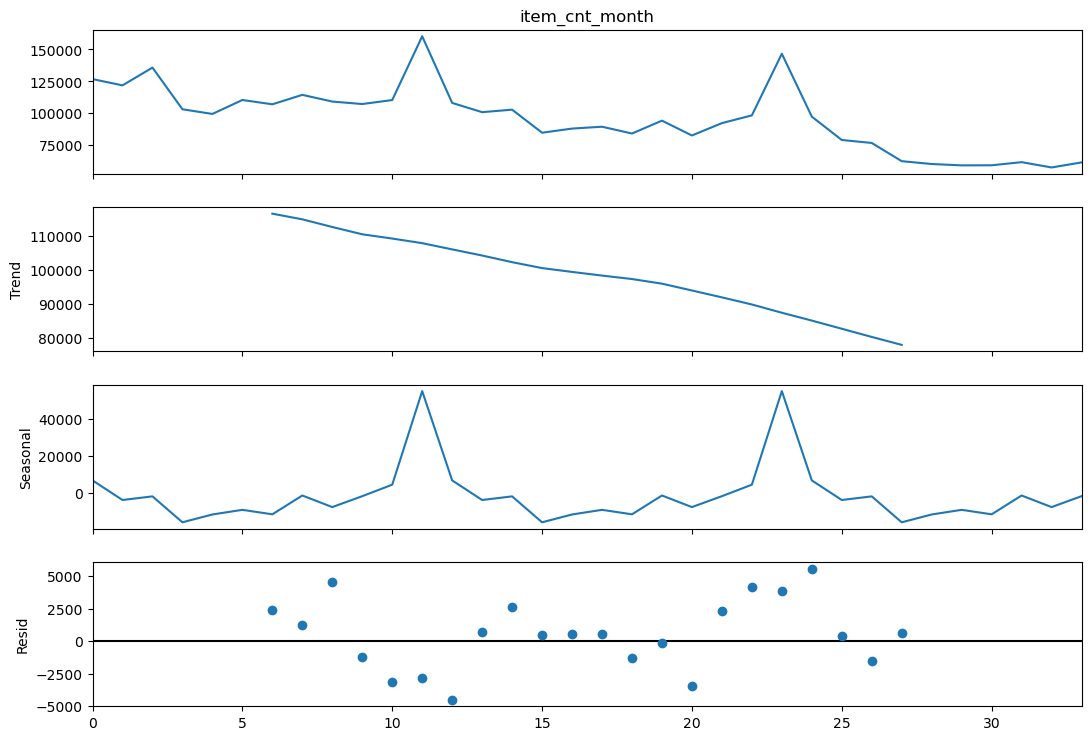

In [439]:
# декомпозиция временнного ряда 
from statsmodels.tsa.seasonal import seasonal_decompose

monthly = (
    df_month
    .groupby('date_block_num', as_index=False)['item_cnt_month']
    .sum()
)
plt.figure(figsize=(12,4))
sns.lineplot(
    data=monthly,
    x='date_block_num',
    y='item_cnt_month'
)
#
plt.title('Общий тренд месячных продаж')
plt.xlabel('Месяц (date_block_num)')
plt.ylabel('Сумма продаж')
plt.show()

monthly_ts = monthly.set_index('date_block_num')['item_cnt_month']
decomp = seasonal_decompose(monthly_ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()

В декомпозиции временного ряда отчетливо видно:

- сезонность: пики продаж приходят на декабрь (справедливо учитывая новогодние праздники), мы предсказываем ноябрь, а мы видим по тренду, что каждый год продажи начинают расти с октября и вплость до декабря, соотвественно зная продажи в октябре, можем спрогнозировать ноябрь увеличив октябрь

- тренд: по тренду видим, что если смотреть в долгосрочной перспективе - то наши продажи с каждым месяцем падают, а значит можем расчитывать, что они в ноябре 2015 будут меньше чем в ноябре 2014 и 2013

Итак, благодря тренду и сезонности уже имеем приблизительные нижнюю и верхние границы

- residual:  в остатках мы видны лишь случайные отклонения, значит модель наша хорошо вычленила тренд и сезонность 



C:\Users\Barys\AppData\Local\Temp\ipykernel_10840\3009497906.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


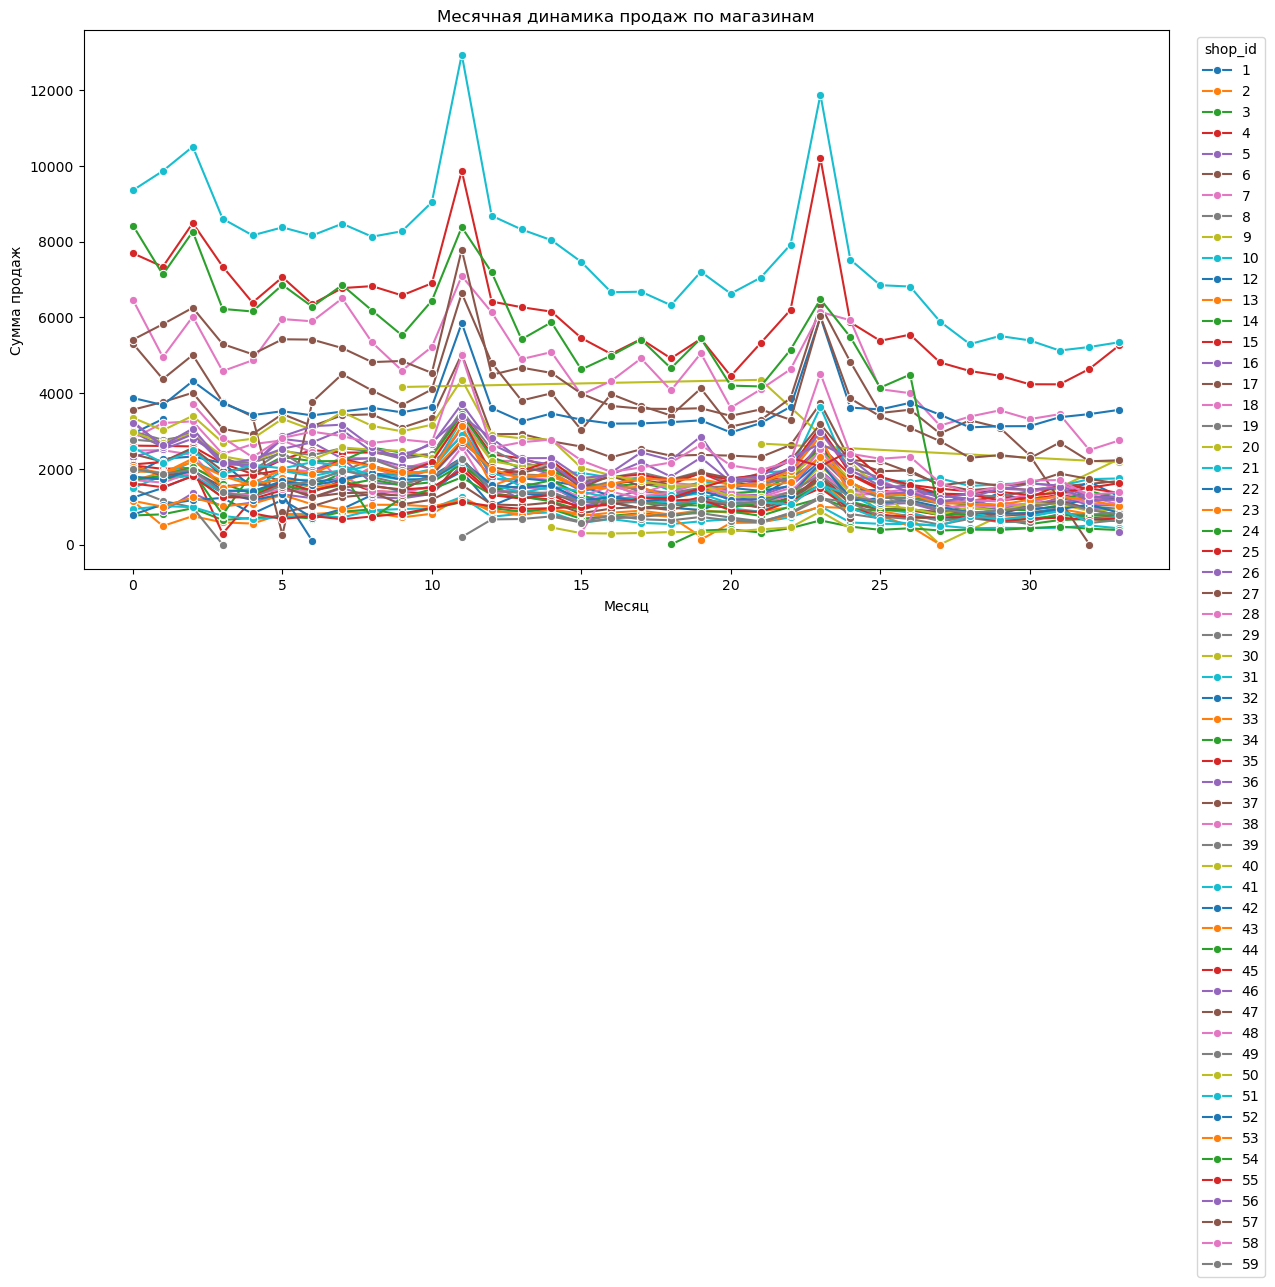

In [440]:
# построим месячную динамику продаж по магазинам
df_plot = (
    df_month
      .groupby(['date_block_num', 'shop_id'])['item_cnt_month']
      .sum()
      .reset_index()
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_plot,
    x='date_block_num',
    y='item_cnt_month',
    hue='shop_id',
    palette='tab10',
    marker='o'
)
plt.xlabel('Месяц')
plt.ylabel('Сумма продаж')
plt.title('Месячная динамика продаж по магазинам')
plt.legend(title='shop_id', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Видим, что у магазина "Жуковский ул. Чкалова 39м:" самые высокие продажи вообще по всем месяцам

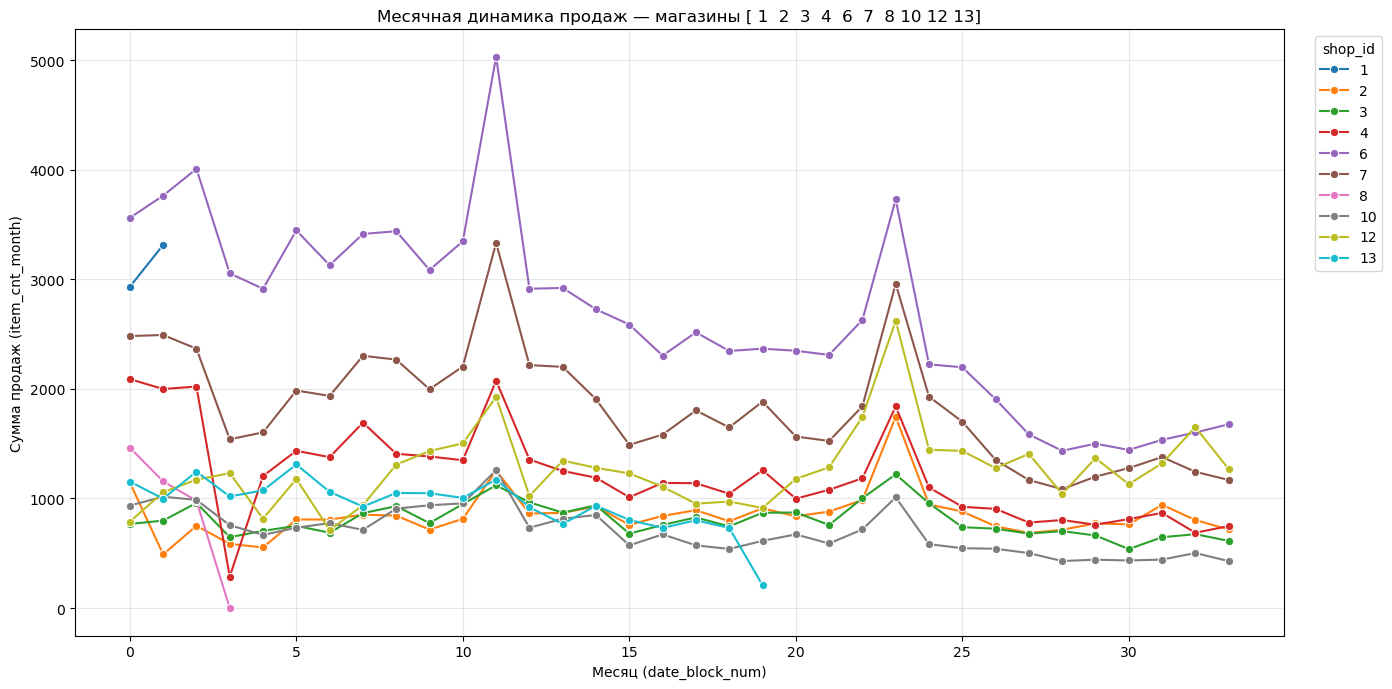

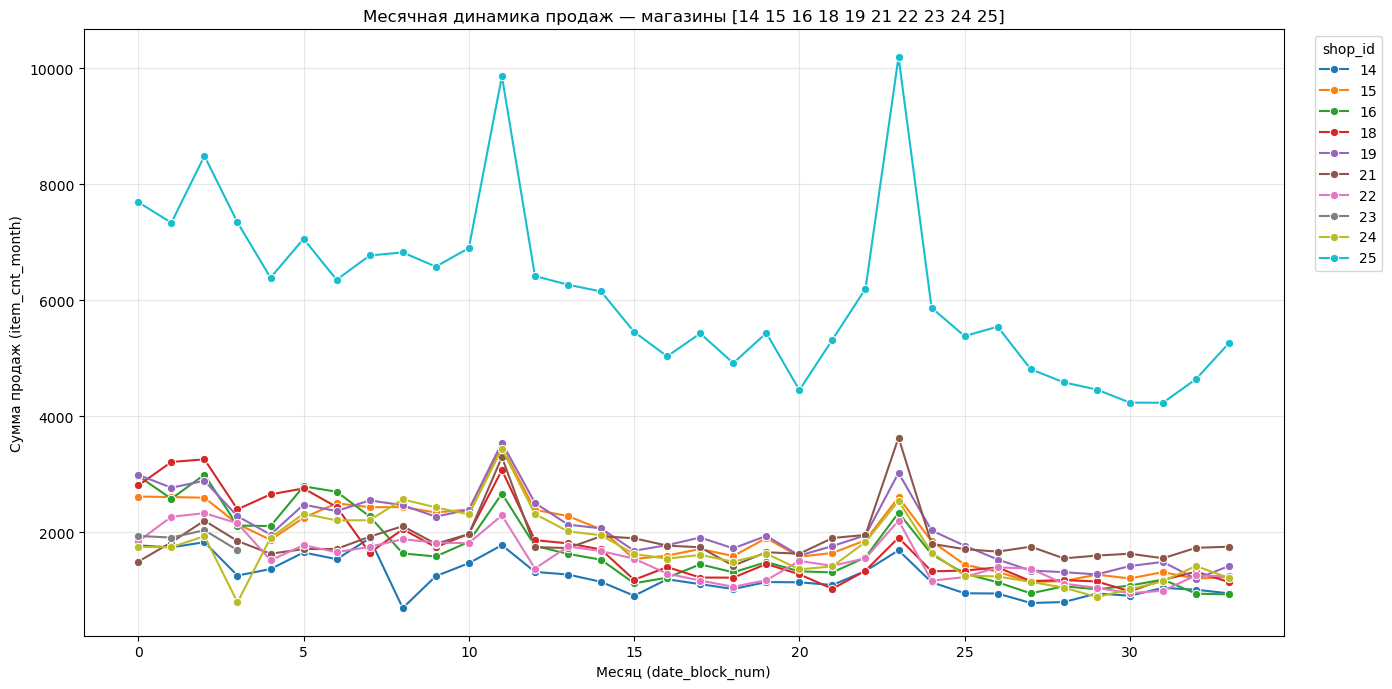

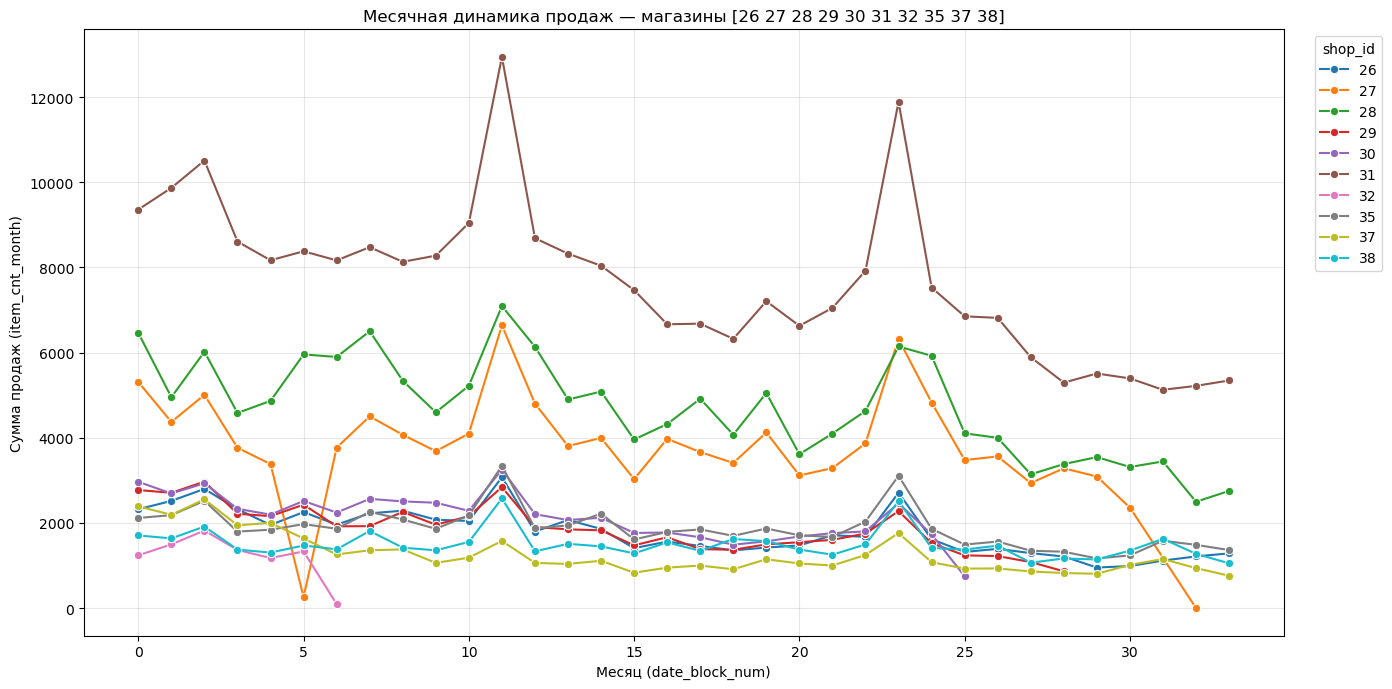

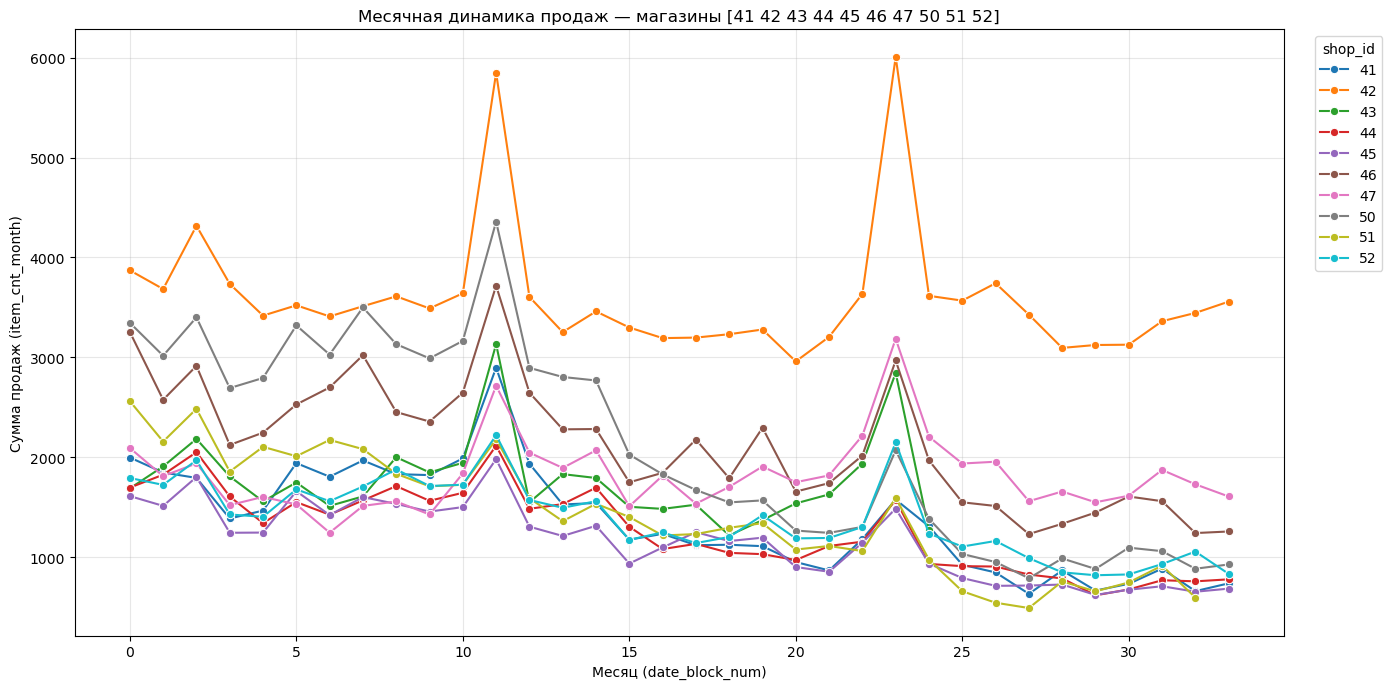

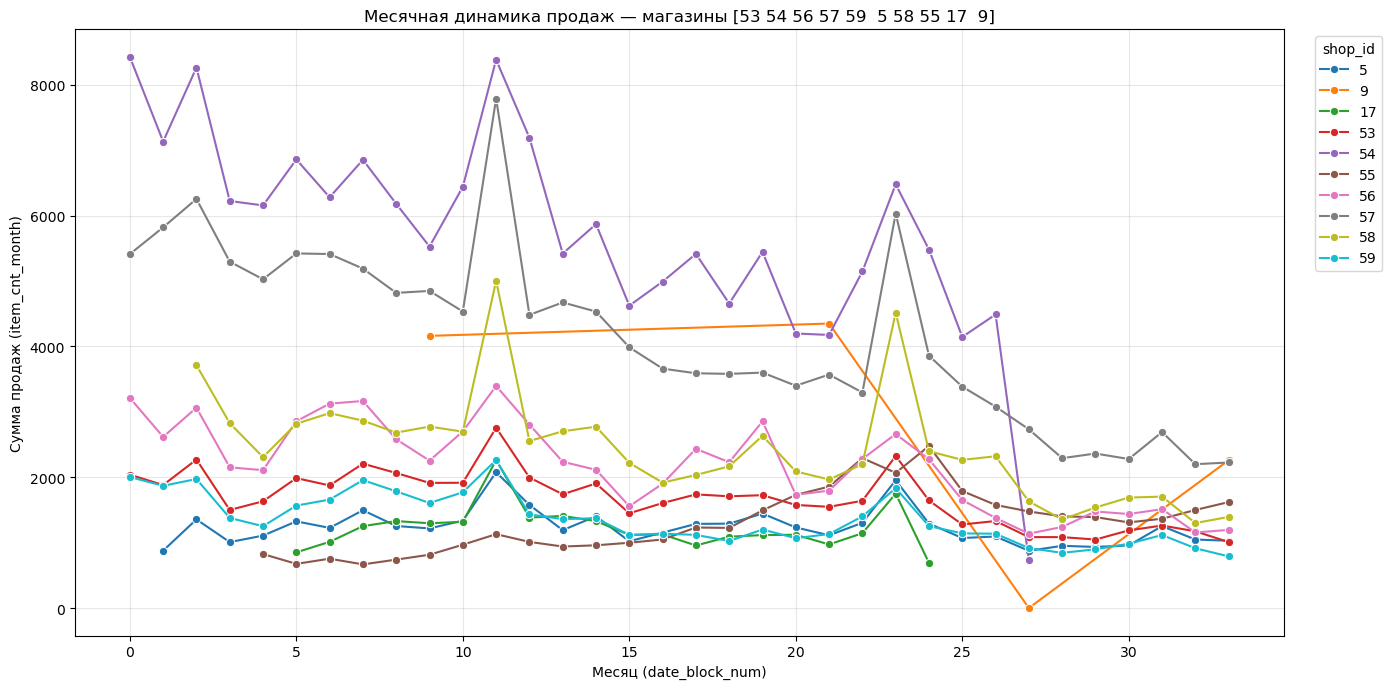

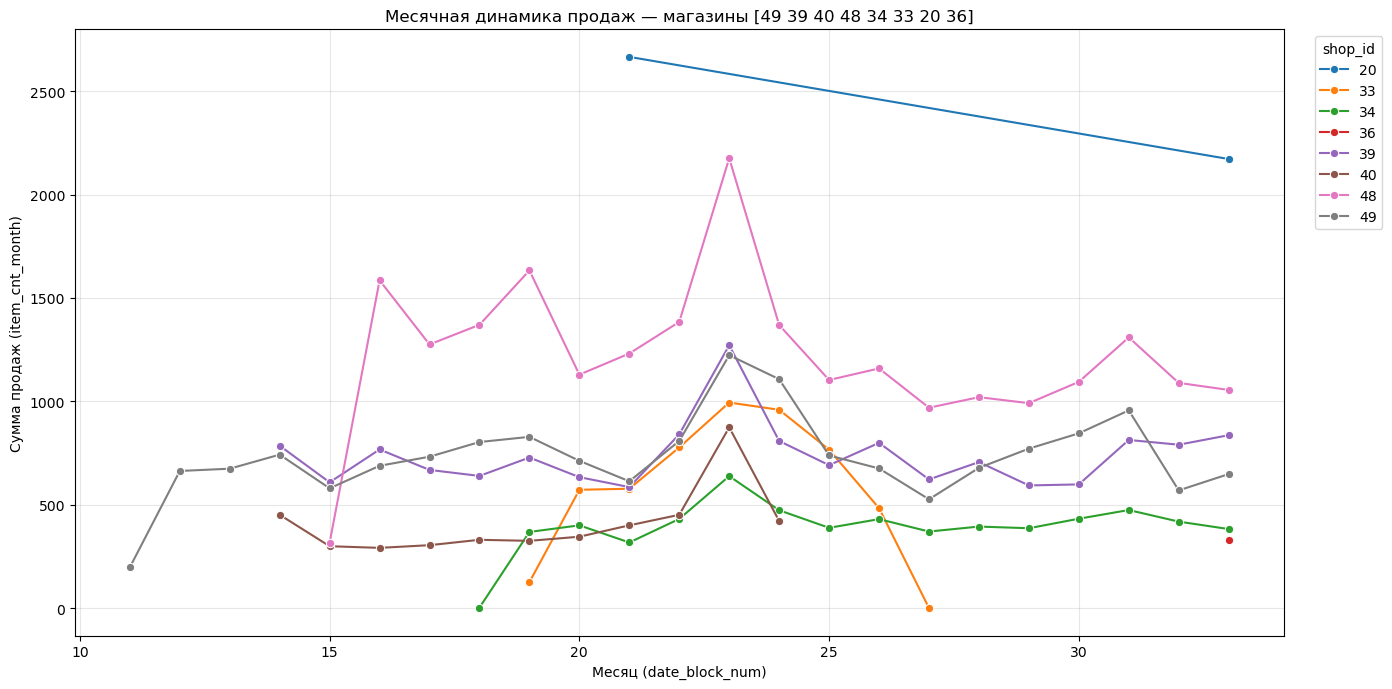

In [441]:
# для удобства будем отображать по 10 магазинов на графике
df_plot = (
    df_month
      .groupby(['date_block_num', 'shop_id'])['item_cnt_month']
      .sum()
      .reset_index()
)

all_shops = df_plot['shop_id'].unique()

def chunk_list(lst, n):
    
    return [lst[i:i + n] for i in range(0, len(lst), n)]

shop_chunks = chunk_list(all_shops, 10)

for chunk in shop_chunks:
    df_chunk = df_plot[df_plot['shop_id'].isin(chunk)]
    
    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=df_chunk,
        x='date_block_num',
        y='item_cnt_month',
        hue='shop_id',
        palette=sns.color_palette('tab10', n_colors=len(chunk)),
        marker='o'
    )
    
    plt.xlabel('Месяц (date_block_num)')
    plt.ylabel('Сумма продаж (item_cnt_month)')
    plt.title(f'Месячная динамика продаж — магазины {chunk}')
    plt.legend(title='shop_id', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


C:\Users\Barys\AppData\Local\Temp\ipykernel_10840\652468850.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


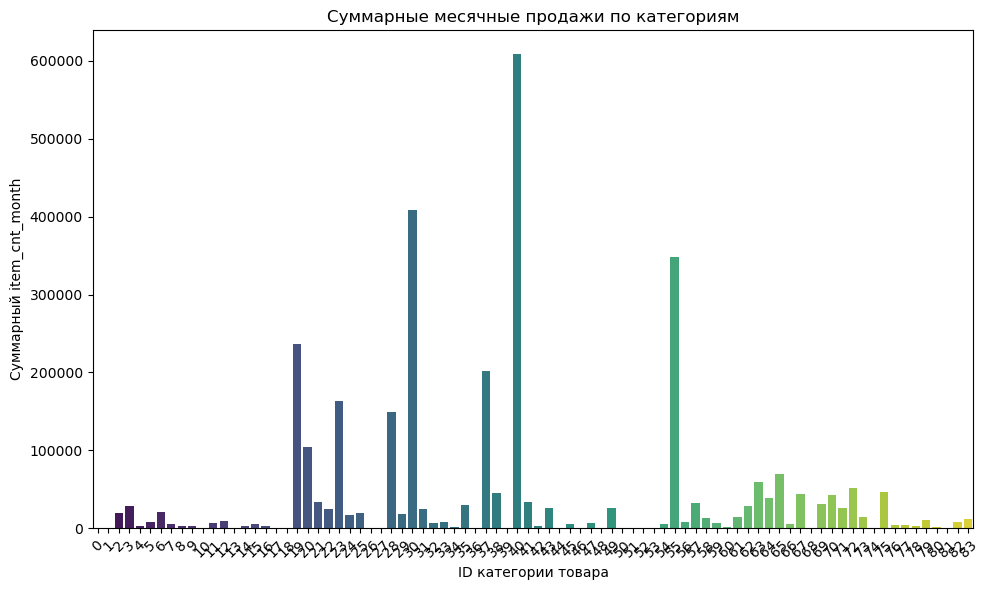

In [442]:
category_sales = (
    df_month
      .groupby('item_category_id')['item_cnt_month']
      .sum()
      .reset_index()
      .sort_values('item_cnt_month', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_sales,
    x='item_category_id',
    y='item_cnt_month',
    palette='viridis'
)
plt.title('Суммарные месячные продажи по категориям')
plt.xlabel('ID категории товара')
plt.ylabel('Суммарный item_cnt_month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Видим, что лучше всего за весь период продавалась категория 40: Кино - DVD

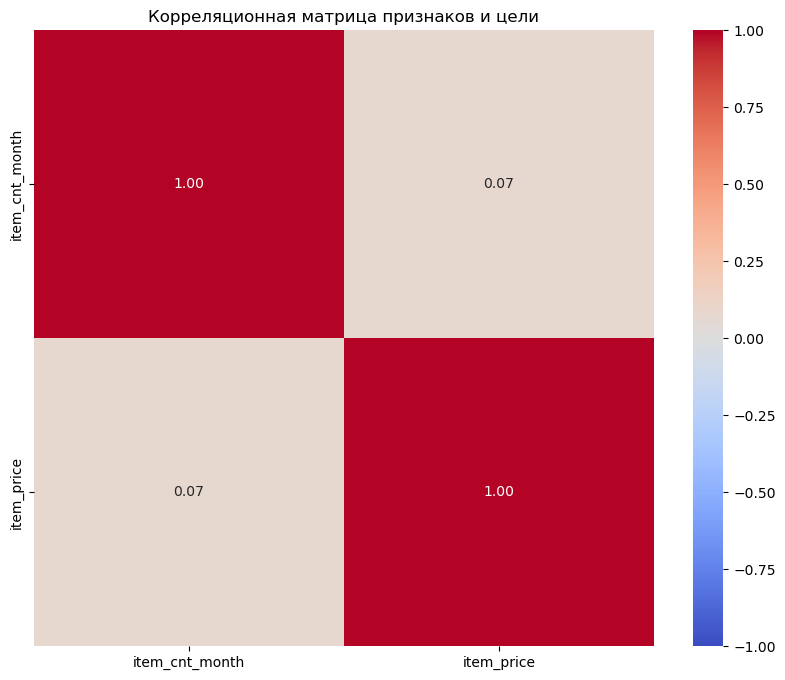

In [443]:
cols = [
    'item_cnt_month',
    'item_price'
]

corr = df_month[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",         
    cmap="coolwarm",   
    vmin=-1, vmax=1
)
plt.title("Корреляционная матрица признаков и цели")
plt.show()


Видим, что у нас на данном этапе почти все признаки категориальные, числовых только два, хотелось бы больше новых признаков, чтобы построить более информативную корреляционную матрицу.

In [444]:
import re
def clean_name(s):
    s = s.lower().strip()
    s = re.sub(r"[^а-яa-z0-9\s]", "", s)
    return s

In [445]:
df_item_categories = pd.read_csv("D:/ML_innovise/item_categories.csv")

In [446]:
df_item_categories['category_clean'] = df_item_categories['item_category_name'].apply(clean_name)

In [447]:
# сделаем новые категории товаров
df_item_categories['simple_category_name'] = (
    df_item_categories['category_clean']
      .str.split()            
      .str[0]                  
)


In [448]:
df_item_categories['simple_category_id'] = pd.factorize(df_item_categories['simple_category_name'])[0]
df_item_categories.head() # посмотрим на результат

,item_category_name,item_category_id,category_clean,simple_category_name,simple_category_id
0,PC - Гарнитуры/Наушники,0,pc гарнитурынаушники,pc,0
1,Аксессуары - PS2,1,аксессуары ps2,аксессуары,1
2,Аксессуары - PS3,2,аксессуары ps3,аксессуары,1
3,Аксессуары - PS4,3,аксессуары ps4,аксессуары,1
4,Аксессуары - PSP,4,аксессуары psp,аксессуары,1


In [449]:
df_item_categories['simple_category_name'].value_counts()

simple_category_name
игры          14
книги         13
подарки       12
игровые        8
аксессуары     7
программы      6
музыка         6
кино           5
карты          5
чистые         2
служебные      2
доставка       1
билеты         1
pc             1
элементы       1
Name: count, dtype: int64

In [450]:
df_month = df_month.merge(
    df_item_categories[['item_category_id', 'simple_category_id']],
    on = ['item_category_id'],
    how='inner'
)


In [451]:
df_month_test = df_month_test.merge(
    df_item_categories[['item_category_id', 'simple_category_id']],
    on = ['item_category_id'],
    how='inner'
)

Чем поможет этот признак: поскольку до этого у нас были слишком разрозненные категории, компьютер считывал разные id у, например:

- Игровые консоли - PS2,10
- Игровые консоли - PS3,11

И считал это абсолютно разными категориями и ему было абсолютно все равно, что и там и там PS.

Теперь с новыми категориями компьютер будет видеть связь между этими товарами.

In [452]:
cat_series = (
    df_month
      .groupby(['item_category_id','date_block_num'])['item_cnt_month']
      .sum()
      .reset_index()
)

In [453]:
df_month['simple_category_id'].value_counts()

simple_category_id
7     526436
5     441215
9     298116
10    202341
8      44104
1      37438
11     30669
4      12204
6      11102
14      2455
12      1384
13      1137
2        314
3        202
0          3
Name: count, dtype: int64

In [454]:
cat_id = 4
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)


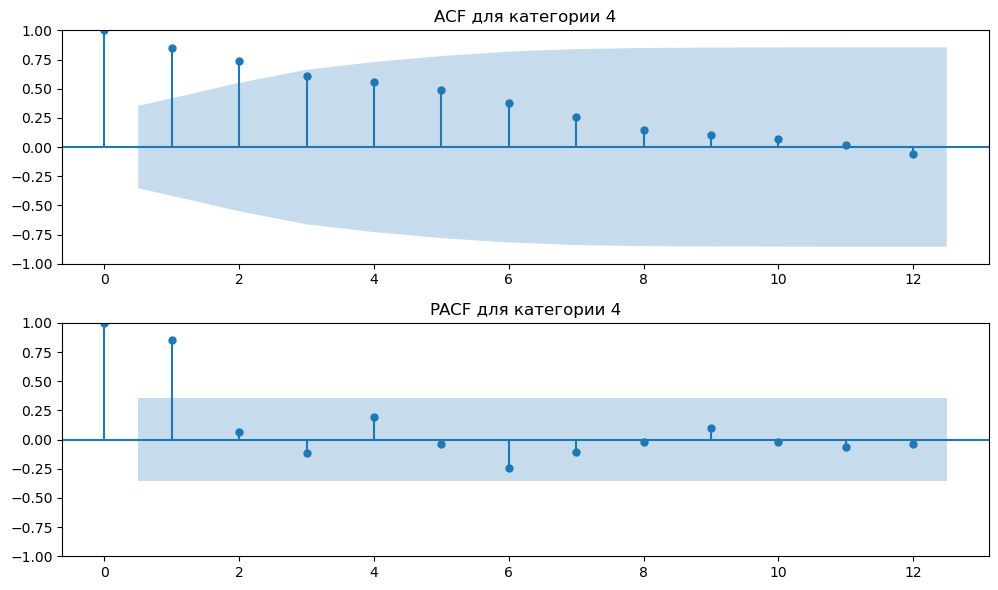

In [455]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()


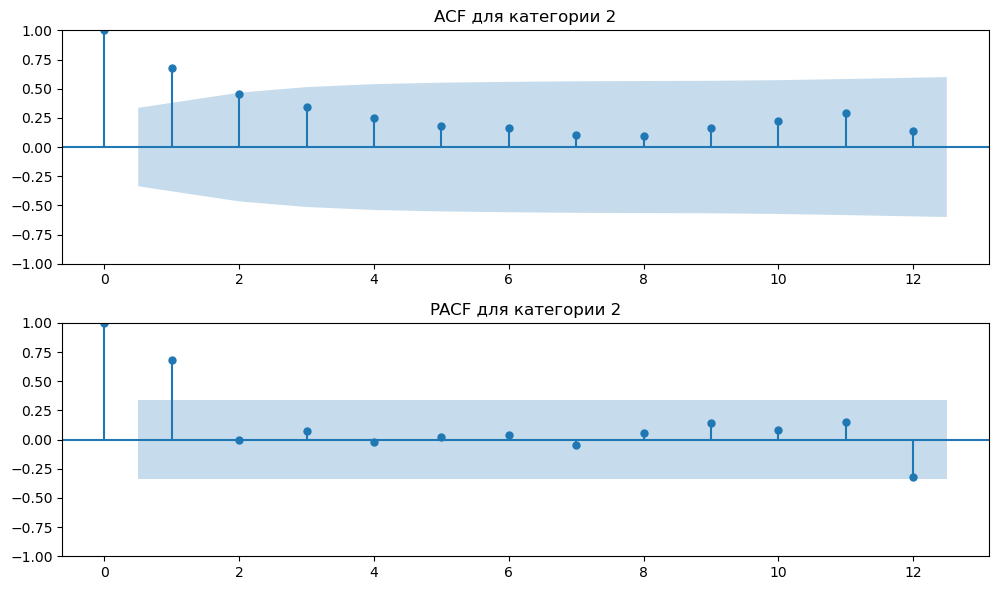

In [456]:
cat_id = 2
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()

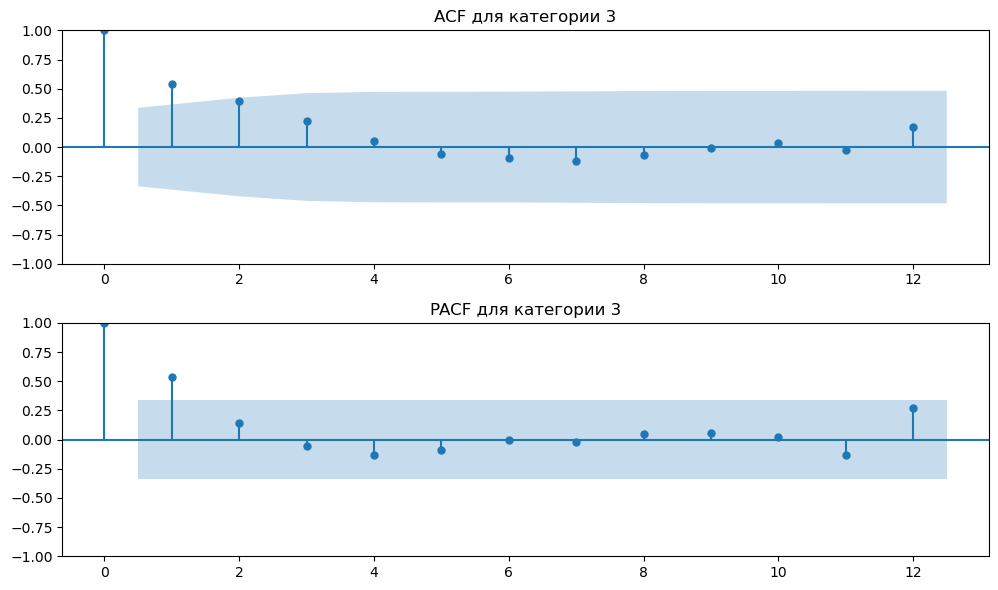

In [457]:
cat_id = 3
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()

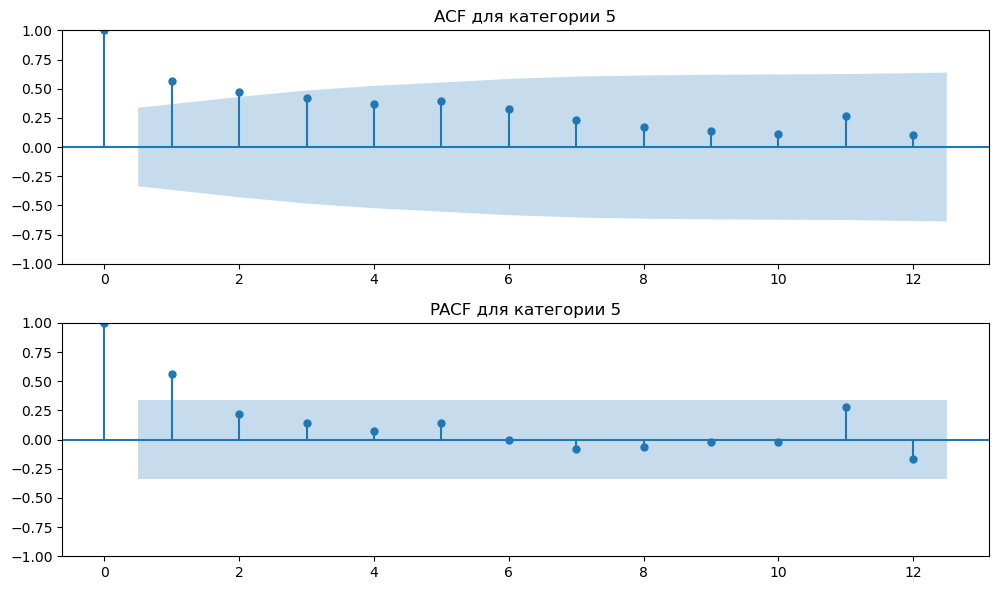

In [458]:
cat_id = 5
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()

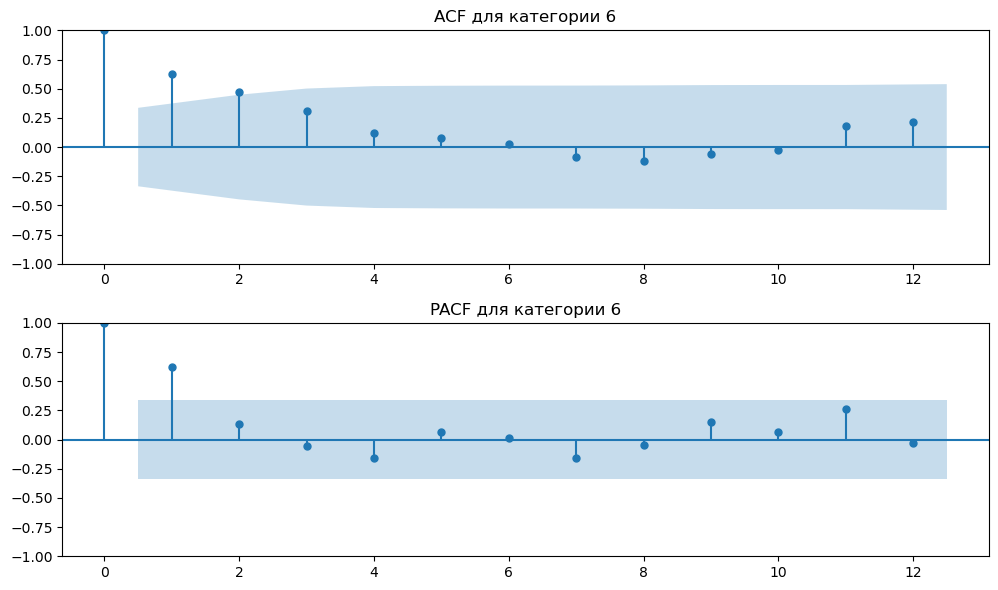

In [459]:
cat_id = 6
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()

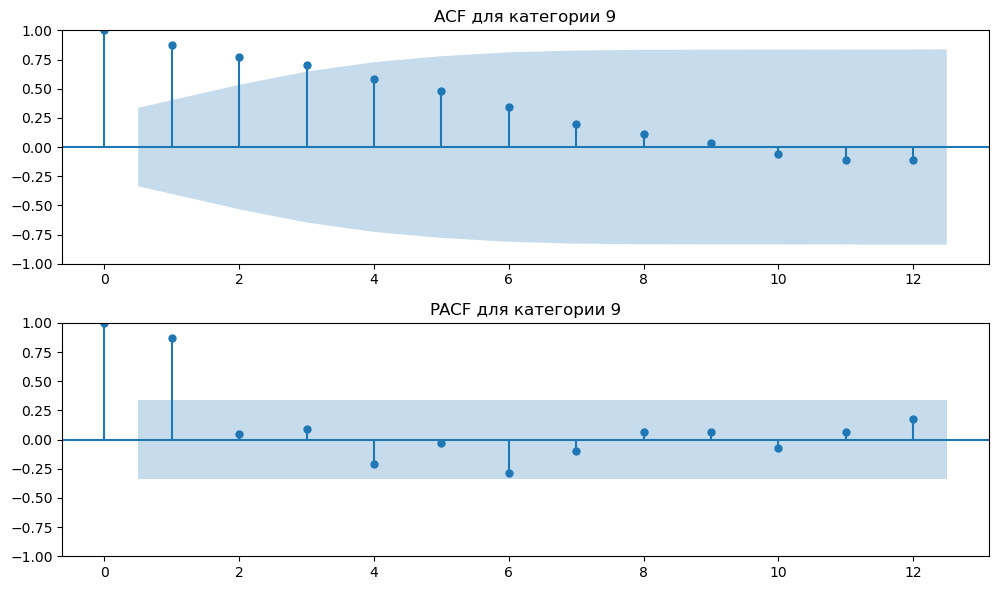

In [460]:
cat_id = 9
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()

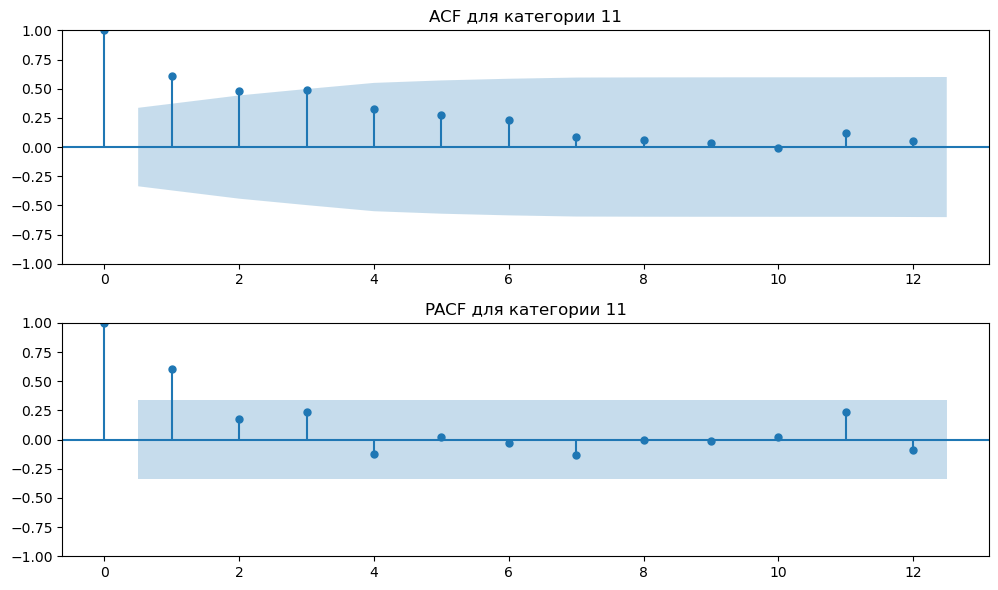

In [461]:
cat_id = 11
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()

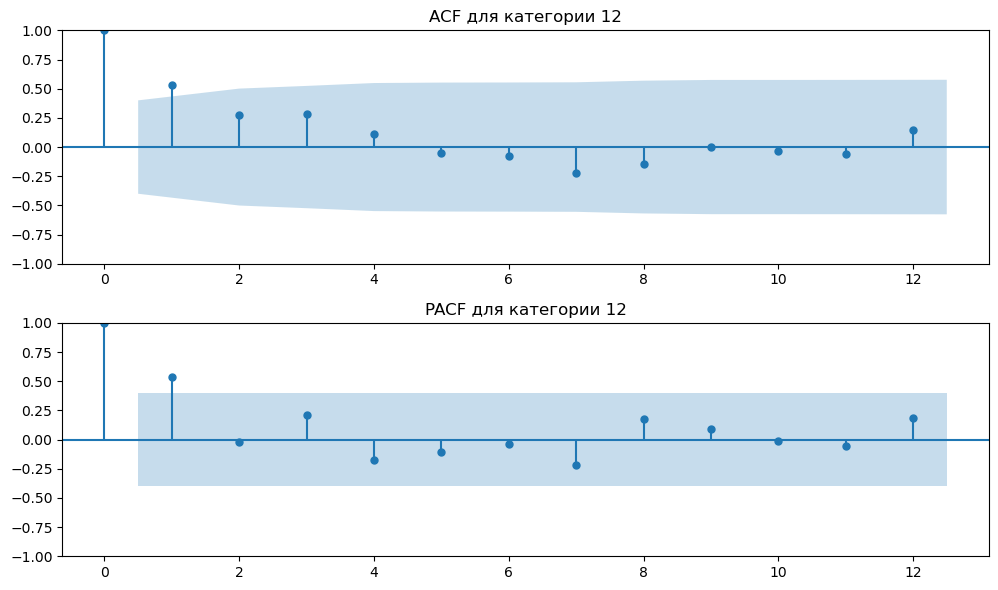

In [462]:
cat_id = 12
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()

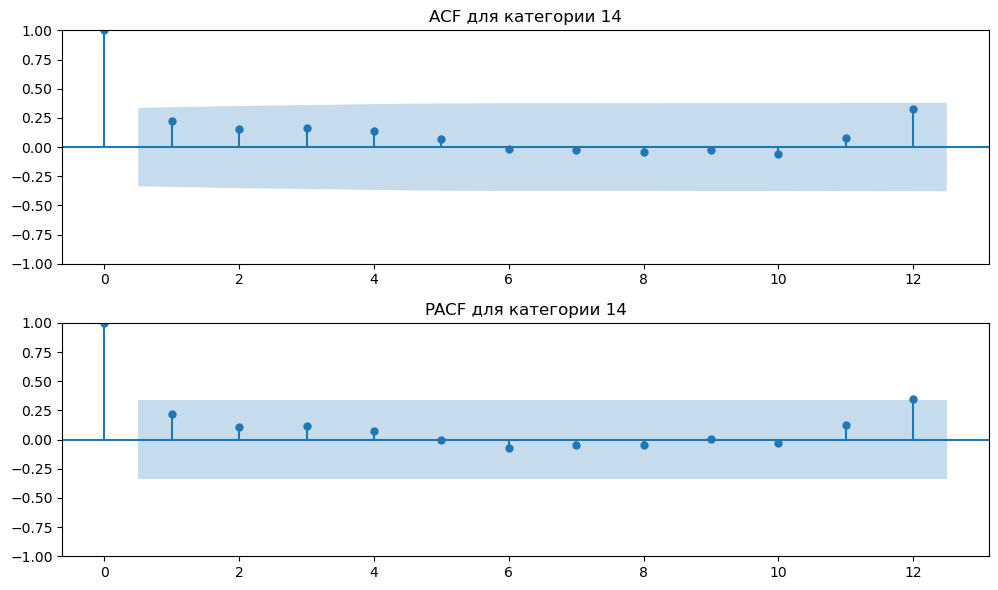

In [463]:
cat_id = 14
series = (
    cat_series[cat_series["item_category_id"] == cat_id]
    .sort_values("date_block_num")
    .set_index("date_block_num")["item_cnt_month"]
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(series, lags=12, ax=axes[0])
axes[0].set_title(f"ACF для категории {cat_id}")

plot_pacf(series, lags=12, ax=axes[1])
axes[1].set_title(f"PACF для категории {cat_id}")

plt.tight_layout()
plt.show()

Поскольку дальше я собираюсь строить лаги и скользящие средние, я решила воспользоваться мудрым советом моего ментора, а именно:

Я посмотрела автокорреляцию и частичную автокорреляцию для продаваемости по категориям товаров.

- заметно, что на графиках автокорреляции lag1 явно выходит за границы доверительного интервала, чем дальше, тем больше затухают, иногда лаг2, лаг3

- на графике частичной автокорреляции видна чистая связь только в лаг1, иногда лаг2


Мои выводы по графикам:

Строим лаги: lag1, lag2, lag3, lag12

Скользящие средние: rm_3, rm_6

In [464]:
df_items = pd.read_csv('D:\ML_innovise\items.csv')

df_items = df_items.merge(
    df_item_categories,
    on='item_category_id',
    how='outer',     
    validate='many_to_one'
)

In [465]:
df_items.head()

,item_name,item_id,item_category_id,item_category_name,category_clean,simple_category_name,simple_category_id
0,PC: Гарнитура HyperX Cloud Core игровая стерео...,5441,0,PC - Гарнитуры/Наушники,pc гарнитурынаушники,pc,0
1,Наушники PHILIPS SBC HC8680,16255,0,PC - Гарнитуры/Наушники,pc гарнитурынаушники,pc,0
2,Наушники RITMIX RH-120,16256,0,PC - Гарнитуры/Наушники,pc гарнитурынаушники,pc,0
3,Наушники RITMIX RH-124 Black,16257,0,PC - Гарнитуры/Наушники,pc гарнитурынаушники,pc,0
4,PS2: Карта памяти 8 Мб черная (Memory Card 8Mb...,5606,1,Аксессуары - PS2,аксессуары ps2,аксессуары,1


In [466]:
df_month_test.head()

,shop_id,item_id,item_category_id,date_block_num,simple_category_id
0,5,5037,19,34,5
1,5,5320,55,34,9
2,5,5233,19,34,5
3,5,5232,23,34,5
4,5,5268,20,34,5


In [467]:
test_pairs = (
    df_month_test
      [['shop_id','item_id','item_category_id','simple_category_id']]
      .drop_duplicates()
)


ЧТо я делаю дальше:
- поскольку у нас нет данных о продажах вообще за каждый месяц, то при подсчете лагов и скользящих средних через shift сработает все неправильно
- поэтому я построю каркас panel, с нулями по продажам вообще за все месяцы
- потом смерджу с реальными историями продаж
- а потом уже посчитаю лаги 

In [468]:
months = pd.DataFrame({'date_block_num': np.arange(35)})

panel = test_pairs.merge(months, how='cross')

panel['item_cnt_month']= 0
panel['item_price']= 0.0


In [469]:
panel = panel.merge(

    df_month[['shop_id','item_id','date_block_num','item_cnt_month']],
    on=['shop_id','item_id','date_block_num'],
    how='left',
    suffixes=('', '_hist')
)
panel['item_cnt_month'] = panel['item_cnt_month_hist'].fillna(0)
panel.drop(columns=['item_cnt_month_hist'], inplace=True)

panel = panel.merge(
    df_month[['shop_id','item_id','date_block_num','item_price']],
    on=['shop_id','item_id','date_block_num'],
    how='left',
    suffixes=('', '_hist')
)


panel['item_price'] = panel['item_price_hist']

panel.drop(columns=['item_price_hist'], inplace=True)


In [470]:
panel.sort_values(
    ['shop_id','item_id','date_block_num'],
    inplace=True
)

In [471]:
median_price_simple = (
    df_month
    .loc[df_month.item_price > 0]                  
    .groupby('simple_category_id')['item_price']
    .median()
)

panel['cum_sum']= panel.groupby('item_id')['item_price'].cumsum()
panel['cum_count'] = panel.groupby('item_id')['item_price'].transform(lambda x: x.notna().cumsum())

panel['cum_sum_prev']= panel.groupby('item_id')['cum_sum'].shift(1)

panel['cum_count_prev']= panel.groupby('item_id')['cum_count'].shift(1)

panel['item_avg_price_prev'] = (panel['cum_sum_prev'])/(panel['cum_count_prev'])

panel['avg_price_prev_missing'] = panel['item_avg_price_prev'].isna().astype(int)
panel['item_avg_price_prev'] = panel['item_avg_price_prev'].fillna(panel['simple_category_id'].map(median_price_simple))
#panel['item_avg_price_prev'] = panel['item_avg_price_prev'].fillna(0)

panel.drop( columns=['cum_sum', 'cum_count','cum_sum_prev','cum_count_prev'], inplace=True)

In [472]:
for lag in [1,2, 3,12]:
    panel[f'cnt_lag_{lag}'] = (
        panel
          .groupby([ 'shop_id','item_id'])['item_cnt_month']
          .shift(lag).fillna(0)
    )

for w in [3,6]:
    panel[f'cnt_rm_{w}'] = (
        panel
          .groupby(['shop_id','item_id'])['item_cnt_month']
          .transform(lambda x, w=w: 
             x.shift(1).rolling(w, min_periods=1).mean()).fillna(0)
    )


In [473]:
panel.head()

,shop_id,item_id,item_category_id,simple_category_id,date_block_num,item_cnt_month,item_price,item_avg_price_prev,avg_price_prev_missing,cnt_lag_1,cnt_lag_2,cnt_lag_3,cnt_lag_12,cnt_rm_3,cnt_rm_6
804545,2,30,40,7,0,0.0,NaN,199.0,1,0.0,0.0,0.0,0.0,0.000000,0.000000
804546,2,30,40,7,1,0.0,NaN,199.0,1,0.0,0.0,0.0,0.0,0.000000,0.000000
804547,2,30,40,7,2,1.0,359.0,199.0,1,0.0,0.0,0.0,0.0,0.000000,0.000000
804548,2,30,40,7,3,0.0,NaN,359.0,0,1.0,0.0,0.0,0.0,0.333333,0.333333
804549,2,30,40,7,4,0.0,NaN,199.0,1,0.0,1.0,0.0,0.0,0.333333,0.250000


In [474]:
panel['item_price'] = panel['item_price'].fillna(0)


In [475]:
df_month_features= panel[panel['date_block_num'] < 34].reset_index(drop=True)
df_month_test = panel[panel['date_block_num'] == 34].drop(columns=['item_cnt_month']).reset_index(drop=True)


In [476]:
df_month_features.head()

,shop_id,item_id,item_category_id,simple_category_id,date_block_num,item_cnt_month,item_price,item_avg_price_prev,avg_price_prev_missing,cnt_lag_1,cnt_lag_2,cnt_lag_3,cnt_lag_12,cnt_rm_3,cnt_rm_6
0,2,30,40,7,0,0.0,0.0,199.0,1,0.0,0.0,0.0,0.0,0.000000,0.000000
1,2,30,40,7,1,0.0,0.0,199.0,1,0.0,0.0,0.0,0.0,0.000000,0.000000
2,2,30,40,7,2,1.0,359.0,199.0,1,0.0,0.0,0.0,0.0,0.000000,0.000000
3,2,30,40,7,3,0.0,0.0,359.0,0,1.0,0.0,0.0,0.0,0.333333,0.333333
4,2,30,40,7,4,0.0,0.0,199.0,1,0.0,1.0,0.0,0.0,0.333333,0.250000


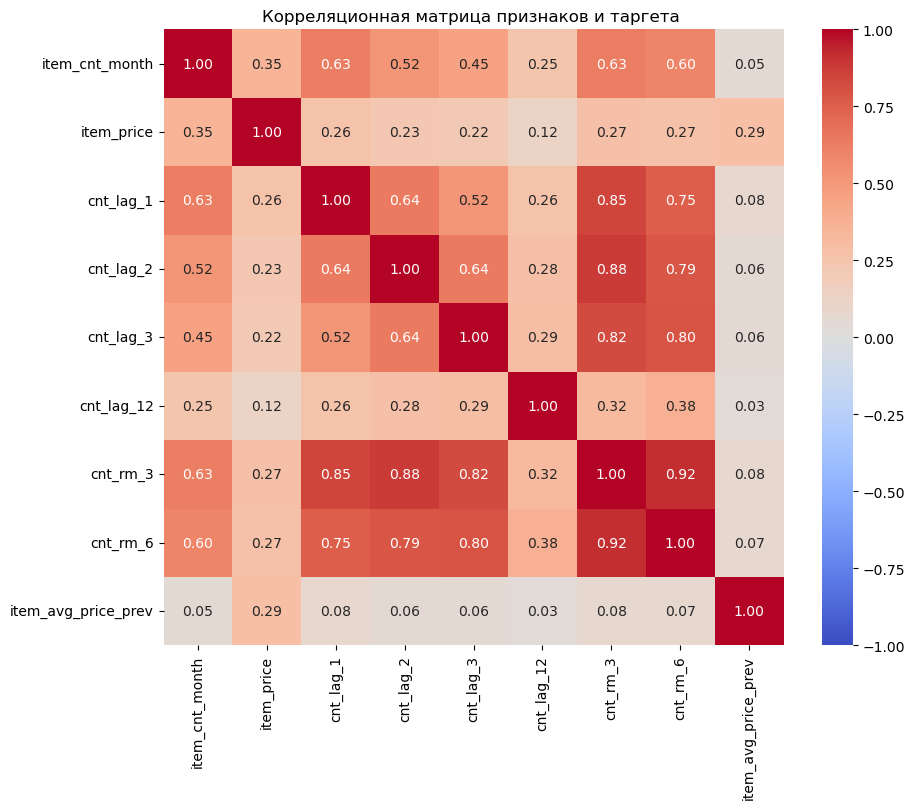

In [477]:
cols = [
    'item_cnt_month',
    'item_price',
    'cnt_lag_1',
    'cnt_lag_2',
    'cnt_lag_3',
    'cnt_lag_12',
    'cnt_rm_3',
    'cnt_rm_6',
    'item_avg_price_prev'
]

corr = df_month_features[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",         
    cmap="coolwarm",   
    vmin=-1, vmax=1
)
plt.title("Корреляционная матрица признаков и таргета ")
plt.show()


Что видим в результате: 
- я добавила новые признаки лаги и скользящие средние, которые довольно неплохо коррелируют с нашим таргетом, что не может не радовать
- я попытались добавить признак, связанный с ценой, который не статичный, не происходит data leakage, но пока он не сильно коррелирует с таргетом 